# Example: Compare Ground Measurements with CAMS CRS Satellite Data

This notebook loads one BSRN station-month via :class:`~bsrn.dataset.BSRNDataset`,
runs the recommended pipeline (``solpos`` → ``clear_sky`` REST2 / MERRA-2 HF →
``qc_test`` → ``qc_mask``), adds CAMS CRS all-sky columns from Hugging Face,
time-averages with :meth:`~bsrn.dataset.BSRNDataset.average`, and plots a
calendar comparison.


In [1]:
import os

import bsrn
from bsrn.io.crs import add_crs_columns
from bsrn.visualization import plot_calendar


## 1. Input path


In [2]:
INPUT_FILE = "/Volumes/Macintosh Research/Data/bsrn-qc/data/QIQ/qiq0824.dat.gz"

print(f"--- Processing {INPUT_FILE} ---")

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"File not found: {INPUT_FILE}")


--- Processing /Volumes/Macintosh Research/Data/bsrn-qc/data/QIQ/qiq0824.dat.gz ---


## 2. Load validated station-month and run the pipeline

``BSRNDataset.from_file`` loads LR0100 plus metadata. Then ``solpos``, ``clear_sky(model='rest2')``, ``qc_test``, and ``qc_mask`` update the cached frame in place.


In [3]:
ds = bsrn.BSRNDataset.from_file(INPUT_FILE)
print(f"Station {ds.station_code}: loaded {len(ds.data())} rows.")

# Pipeline: geometry, REST2 clear-sky, QC flags, then mask failures
print("solpos() …")
ds.solpos()
print("clear_sky(model='rest2') …")
ds.clear_sky(model="rest2")
print("qc_test() …")
ds.qc_test()
print("qc_mask() …")
ds.qc_mask()


Station QIQ: loaded 44640 rows.
solpos() …
clear_sky(model='rest2') …
Fetching MERRA-2 from Hugging Face: qiq/qiq0824_merra2.parquet
qc_test() …
qc_mask() …


,ghi,bni,dhi,lwd,temp,rh,pressure,zenith,apparent_zenith,azimuth,bni_extra,ghi_extra,ghi_clear,bni_clear,dhi_clear,lwd_clear
2024-08-01 00:00:00+00:00,105.0,0.0,106.0,421.0,25.2,70.0,981.0,54.881,54.857,102.414,1320.650,759.739,507.439814,664.498840,125.169227,410.715619
2024-08-01 00:01:00+00:00,108.0,0.0,109.0,422.0,25.2,71.0,981.0,54.717,54.694,102.625,1320.650,762.828,509.994881,665.753119,125.445597,411.548727
2024-08-01 00:02:00+00:00,112.0,0.0,113.0,421.0,25.2,70.0,981.0,54.553,54.530,102.836,1320.650,765.910,512.545982,666.998615,125.720382,410.715619
2024-08-01 00:03:00+00:00,113.0,0.0,114.0,421.0,25.2,70.0,981.0,54.390,54.367,103.049,1320.650,768.968,515.077560,668.227890,125.991932,410.715619
2024-08-01 00:04:00+00:00,116.0,0.0,117.0,421.0,25.2,71.0,981.0,54.226,54.204,103.261,1320.650,772.038,517.620641,669.456101,126.263590,411.548727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31 23:55:00+00:00,123.0,0.0,123.0,371.0,21.9,45.0,988.0,61.982,61.951,110.304,1335.838,627.508,430.077633,741.828764,81.604368,359.041392
2024-08-31 23:56:00+00:00,129.0,0.0,130.0,370.0,21.9,45.0,988.0,61.825,61.794,110.521,1335.838,630.737,432.754922,743.268714,81.808573,359.041392
2024-08-31 23:57:00+00:00,135.0,0.0,136.0,370.0,21.9,46.0,988.0,61.668,61.637,110.738,1335.838,633.962,435.429929,744.697256,82.011590,360.170497
2024-08-31 23:58:00+00:00,138.0,0.0,139.0,370.0,21.9,47.0,988.0,61.511,61.481,110.956,1335.838,637.181,438.102614,746.114514,82.213429,361.278756


## 3. CRS all-sky columns and time averaging

Add 1-minute CRS from Hugging Face **before** averaging. ``ds.average`` uses centered windows and replaces the cache with the averaged frame.


In [4]:
print("add_crs_columns (Hugging Face) …")
add_crs_columns(ds.data(), station_code=ds.station_code)

print("average(freq='30min', alignment='center') …")
df_avg = ds.average(
    "30min",
    alignment="center",
    match_ceiling_labels=True,
)

print("\nProcessing complete. Sample averaged data:")
print(df_avg[["ghi", "ghi_clear", "ghi_crs"]].head())


add_crs_columns (Hugging Face) …
Fetching CRS from Hugging Face: qiq/qiq0824_crs.parquet
average(freq='30min', alignment='center') …

Processing complete. Sample averaged data:
                                  ghi   ghi_clear   ghi_crs
2024-08-01 00:30:00+00:00  181.666667  582.063900  200.3826
2024-08-01 01:00:00+00:00  456.650000  648.930252  420.4916
2024-08-01 01:30:00+00:00  356.782609  707.238474  414.9592
2024-08-01 02:00:00+00:00  291.666667  755.752768  392.6008
2024-08-01 02:30:00+00:00  295.133333  793.024248  375.5578


## 4. Calendar plot


/Volumes/Macintosh Research/Data/bsrn-qc/src/bsrn/visualization/calendar.py:87: UserWarning: Automatically sliced input DataFrame to target month: 2024-08


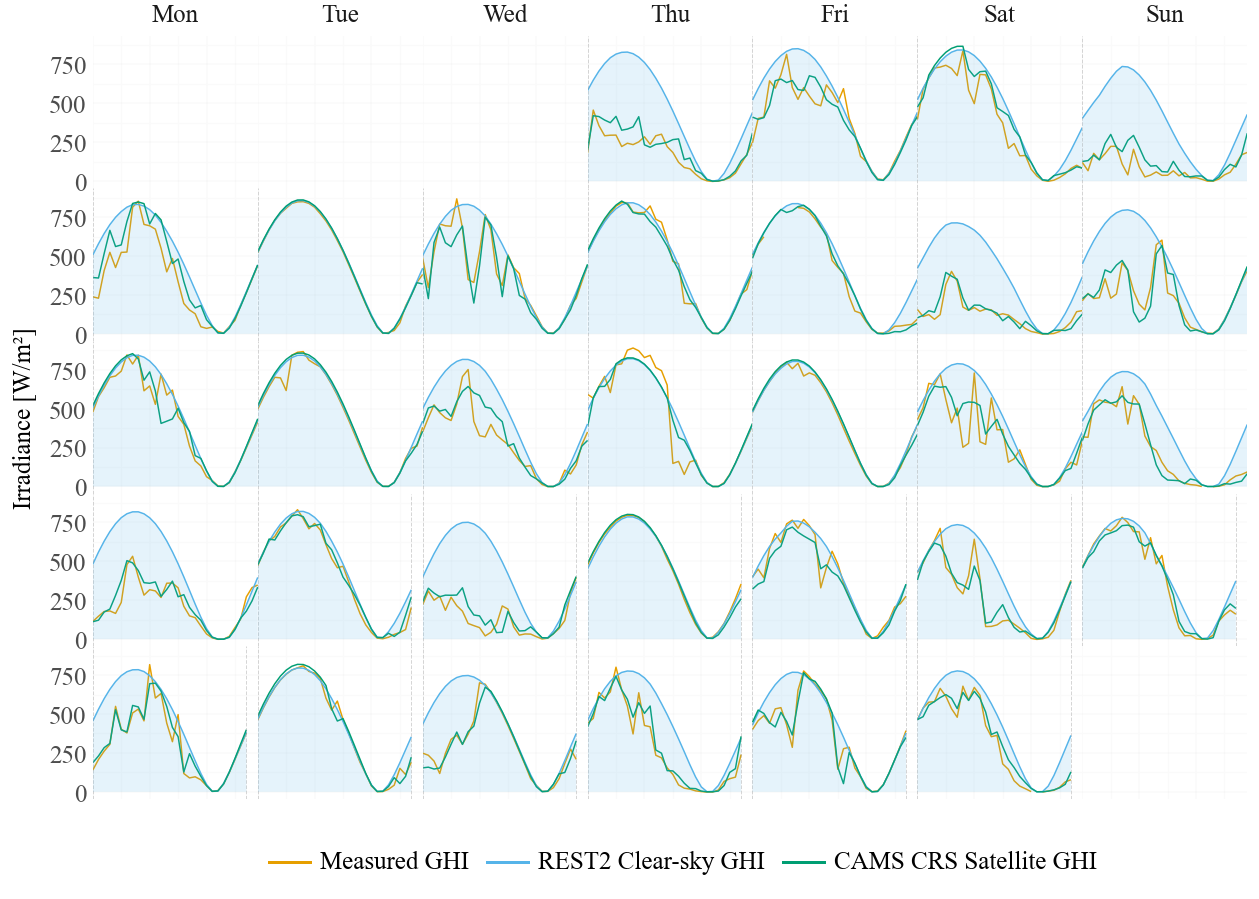

In [5]:
# Calendar helper expects floor-aligned labels for this workflow.
# Use output_file=None to show the figure in the notebook (no PDF).
p = plot_calendar(
    df=df_avg,
    output_file=None,
    meas_col="ghi",
    clear_col="ghi_clear",
    other_cols=["ghi_crs"],
    labels=[
        "Measured GHI",
        "REST2 Clear-sky GHI",
        "CAMS CRS Satellite GHI",
    ],
)
p
